### IMPORTING REQUIRED PACKGES

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import category_encoders as ce
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

### Louding Dataset

In [135]:
x = pd.read_csv(r"C:\Users\HP\Desktop\ML project/Kaltun 45634( project).csv")
x.head()

,S.no,Gender,Age,Marital Status,Education,Institution,EducationField,Study,Work Experience,City,Employed,Enviroment_satisfaction,Jobsatistaction
0,1,Male,24,Single,BS,IIUI,Electrical Engineering,Currently studying,1.5,Islamamabad,NO,yes,0
1,2,Female,25,Single,MS,RIPHAH,information securuty,Currently studying,2.0,Islamamabad,NO,yes,0
2,3,Male,21,Single,BS,IIUI,Economics,Currently studying,0.0,Islamamabad,NO,yes,0
3,4,Male,26,Married,M-Phil,IIUI,physcology,Currently studying,3.0,Islamamabad,NO,NO,0
4,5,Male,23,Single,BS,IIUI,Economics,Currently studying,0.0,Islamamabad,NO,yes,0


In [136]:
x.shape

(80, 13)

In [137]:
x.columns

Index(['S.no', 'Gender', 'Age ', 'Marital Status', 'Education', 'Institution ',
       'EducationField', 'Study', 'Work Experience', 'City', 'Employed',
       'Enviroment_satisfaction', 'Jobsatistaction'],
      dtype='object')

In [138]:
x.isnull().sum()

S.no                       0
Gender                     0
Age                        0
Marital Status             0
Education                  0
Institution                0
EducationField             0
Study                      0
Work Experience            0
City                       0
Employed                   0
Enviroment_satisfaction    0
Jobsatistaction            0
dtype: int64

In [139]:
x.nunique()

S.no                       80
Gender                      2
Age                        17
Marital Status              2
Education                   5
Institution                 3
EducationField             18
Study                       2
Work Experience            21
City                        4
Employed                    2
Enviroment_satisfaction     2
Jobsatistaction             2
dtype: int64

In [140]:
x.dtypes.sort_index()

Age                          int64
City                        object
Education                   object
EducationField              object
Employed                    object
Enviroment_satisfaction     object
Gender                      object
Institution                 object
Jobsatistaction              int64
Marital Status              object
S.no                         int64
Study                       object
Work Experience            float64
dtype: object

### Looking For Duplicate Data

In [141]:
x.duplicated().sum()

0

In [142]:
x.describe()

,S.no,Age,Work Experience,Jobsatistaction
count,80.0000,80.000000,80.000000,80.000000
mean,40.5000,26.300000,2.615000,0.212500
std,23.2379,4.329469,2.539117,0.411658
min,1.0000,19.000000,0.000000,0.000000
25%,20.7500,23.000000,0.000000,0.000000
50%,40.5000,26.000000,2.000000,0.000000
75%,60.2500,30.000000,4.000000,0.000000
max,80.0000,40.000000,10.000000,1.000000


### Data Analysis

In [143]:
employed_count = pd.DataFrame(data['Employed'].value_counts())
employed_count

,Employed
NO,61
YES,19


Text(0.5, 1.0, 'Employed Probability')

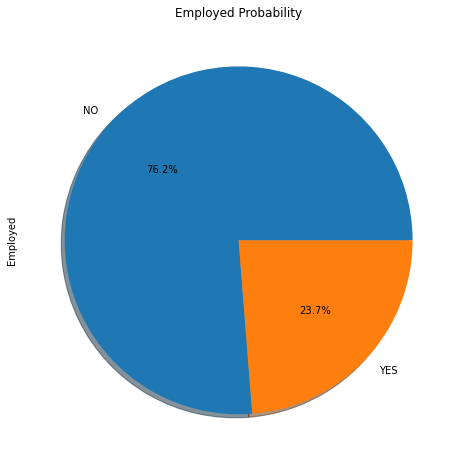

In [144]:
f, ax = plt.subplots(figsize=(8, 8))
ax = x['Employed'].value_counts().plot.pie(explode=[0, 0], autopct='%1.1f%%', shadow=True)
ax.set_title('Employed Probability')

<AxesSubplot:xlabel='Age ', ylabel='count'>

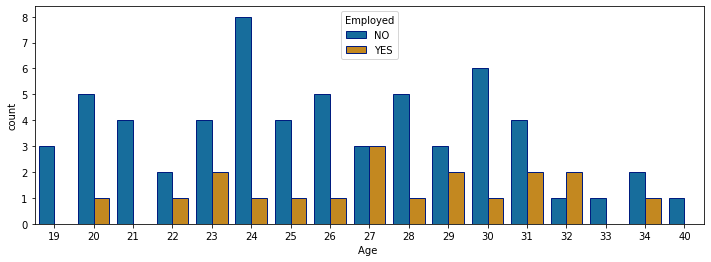

In [149]:
fig_dims = (12, 4)
fig, ax = plt.subplots(figsize=fig_dims)

# ax = axis
sns.countplot(
    x ='Age ',
    hue ='Employed',
    data = data,
    palette="colorblind",
    ax=ax,
    edgecolor=sns.color_palette("dark", n_colors=1),
    )


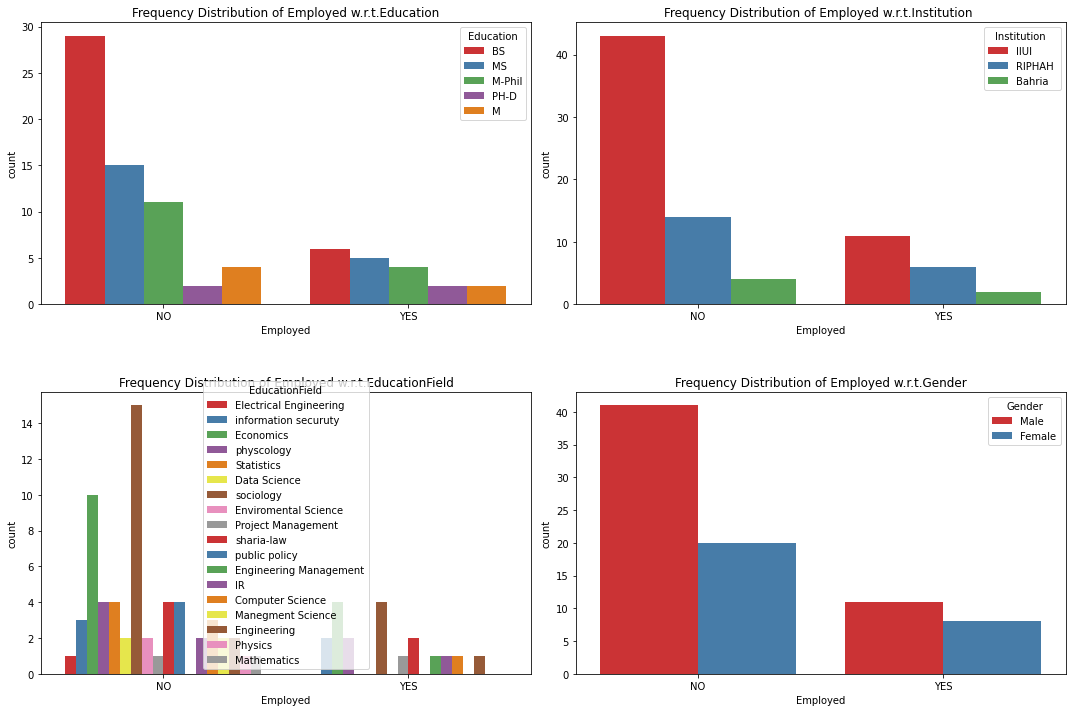

In [150]:
f, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0] = sns.countplot(x='Employed', hue='Education', data=data, ax=ax[0, 0], palette='Set1')
ax[0, 0].set_title("Frequency Distribution of Employed w.r.t.Education")


ax[1, 0] = sns.countplot(x='Employed', hue='EducationField', data=data, ax=ax[1, 0], palette='Set1')
ax[1, 0].set_title("Frequency Distribution of Employed w.r.t.EducationField")

ax[0, 1] = sns.countplot(x='Employed', hue='Institution ', data=data, ax=ax[0, 1], palette='Set1')
ax[0, 1].set_title("Frequency Distribution of Employed w.r.t.Institution ")

ax[1, 1] = sns.countplot(x='Employed', hue='Gender', data=data, ax=ax[1, 1], palette='Set1')
ax[1, 1].set_title("Frequency Distribution of Employed w.r.t.Gender")

f.tight_layout()

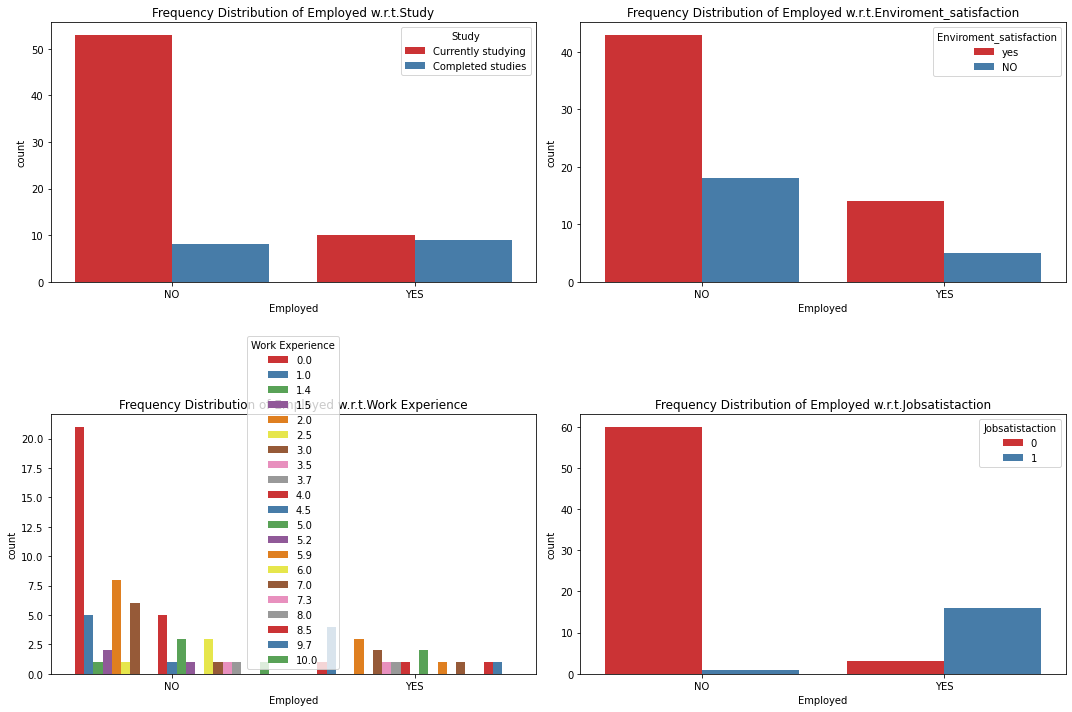

In [151]:
f, ax = plt.subplots(2, 2, figsize=(15, 10))

ax[0, 0] = sns.countplot(x='Employed', hue='Study', data=data, ax=ax[0, 0], palette='Set1')
ax[0, 0].set_title("Frequency Distribution of Employed w.r.t.Study")


ax[1, 0] = sns.countplot(x='Employed', hue='Work Experience', data=data, ax=ax[1, 0], palette='Set1')
ax[1, 0].set_title("Frequency Distribution of Employed w.r.t.Work Experience")

ax[0, 1] = sns.countplot(x='Employed', hue='Enviroment_satisfaction', data=data, ax=ax[0, 1], palette='Set1')
ax[0, 1].set_title("Frequency Distribution of Employed w.r.t.Enviroment_satisfaction")

ax[1, 1] = sns.countplot(x='Employed', hue='Jobsatistaction', data=data, ax=ax[1, 1], palette='Set1')
ax[1, 1].set_title("Frequency Distribution of Employed w.r.t.Jobsatistaction")

f.tight_layout()

## Object data and their unique values

### correlation of the columns

In [152]:
for column in x.columns:
    if x[column].dtype == object:
        print(str(column) + ':' + str(x[column].unique()))
        print(x[column].value_counts())
        print("_"*90)

Gender:['Male' 'Female']
Male      52
Female    28
Name: Gender, dtype: int64
__________________________________________________________________________________________
Marital Status:['Single' 'Married']
Single     55
Married    25
Name: Marital Status, dtype: int64
__________________________________________________________________________________________
Education:['BS ' 'MS' 'M-Phil' 'PH-D' 'M']
BS        35
MS        20
M-Phil    15
M          6
PH-D       4
Name: Education, dtype: int64
__________________________________________________________________________________________
Institution :['IIUI ' 'RIPHAH ' 'Bahria ']
IIUI       54
RIPHAH     20
Bahria      6
Name: Institution , dtype: int64
__________________________________________________________________________________________
EducationField:['Electrical Engineering' 'information securuty' 'Economics' 'physcology'
 'Statistics' 'Data Science ' 'sociology' 'Enviromental Science '
 'Project Management' 'sharia-law' 'public polic

In [153]:
#Remove unneeded columns

#Remove the column Marital Status
x = x.drop ('Marital Status', axis = 1)
#Remove the column City
x = x.drop('City', axis = 1)

In [154]:
data.corr()

,S.no,Age,Work Experience,Jobsatistaction
S.no,1.000000,0.006417,0.105464,0.106521
Age,0.006417,1.000000,0.745398,0.191053
Work Experience,0.105464,0.745398,1.000000,0.276659
Jobsatistaction,0.106521,0.191053,0.276659,1.000000


<AxesSubplot:>

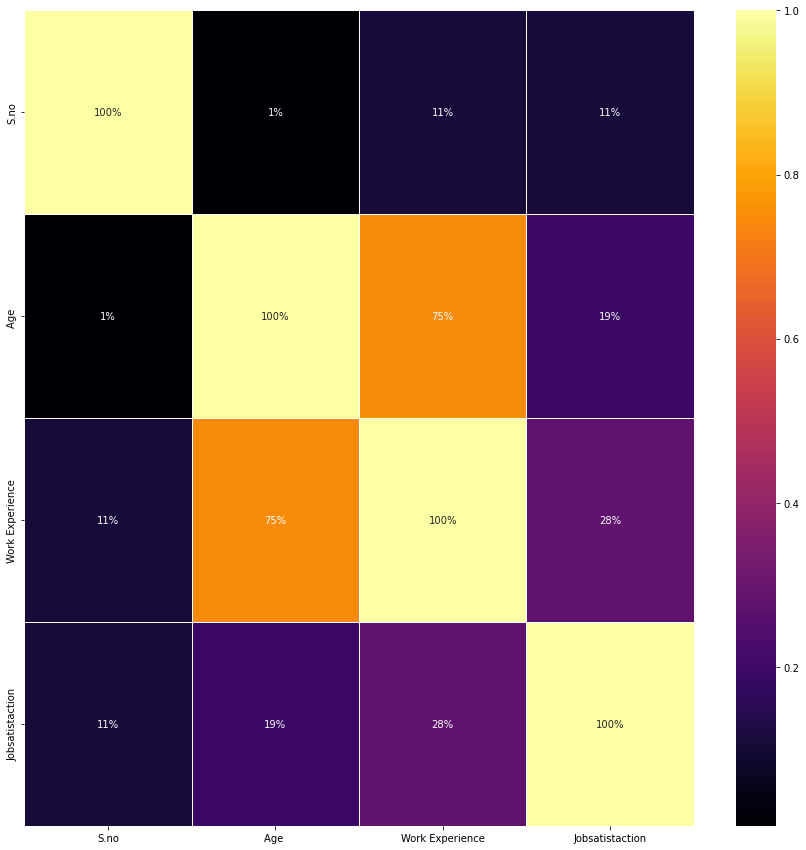

In [116]:
plt.figure(figsize=(15, 15))
sns.heatmap(
    data.corr(),
    annot=True,
    fmt='.0%',
    linewidths=1,
    cmap='inferno'
)          

### Empty markdown cell, double click and press enter to edit

In [155]:
print(x.columns)

Index(['S.no', 'Gender', 'Age ', 'Education', 'Institution ', 'EducationField',
       'Study', 'Work Experience', 'Employed', 'Enviroment_satisfaction',
       'Jobsatistaction'],
      dtype='object')


In [156]:
y = x['Employed']
print(y)

0      NO
1      NO
2      NO
3      NO
4      NO
     ... 
75    YES
76     NO
77     NO
78     NO
79    YES
Name: Employed, Length: 80, dtype: object


### Train test Split

In [158]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [159]:
print(x_train.shape, x_test.shape)

(64, 11) (16, 11)


### Convoerting controcial value to numberical value

In [160]:
encoder = ce.OrdinalEncoder(cols = ['Gender', 'Age ', 'Education', 'Institution ', 'EducationField',
       'Study', 'Work Experience', 'Employed', 'Enviroment_satisfaction',
       'Jobsatistaction'])
x_train = encoder.fit_transform(x_train)
x_test = encoder.fit_transform(x_test)

In [ ]:
#data preprocessing

In [161]:
cols = x_train.columns

scaler = RobustScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train = pd.DataFrame(x_train, columns=cols)
x_test = pd.DataFrame(x_test, columns=cols)

### Building and testing model bt Applying Random forest ML Algorithm 

In [162]:
rfc = RandomForestClassifier(n_estimators=100, random_state=0)
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)

In [163]:
score = accuracy_score(y_test, y_pred)
print('randomforest classifier score: ', np.abs(score)*100)

randomforest classifier score:  100.0


In [164]:
y_pred

array(['NO', 'NO', 'NO', 'YES', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO',
       'NO', 'NO', 'NO', 'NO', 'NO'], dtype=object)